Zestawienie wyników dla lat 1962, 1977, 1992:
 Rok  Prawdziwa wartość  Splajn (not-a-knot)  Błąd (not-a-knot) [%]  Splajn (naturalny)  Błąd (naturalny) [%]  S. clamped  Błąd Clmp [%]  PCHIP  Błąd (PCHIP) [%]  Lagrange  Błąd (Lagrange) [%]
1962              12380                 5146                  58.43               13285                  7.31       24313          96.39  13869             12.03    -77704               727.66
1977              27403                22642                  17.37               22934                 16.31       23126          15.61  25204              8.02     15470                43.55
1992              32059                41894                  30.68               37798                 17.90       22166          30.86  32663              1.89     43191                34.72


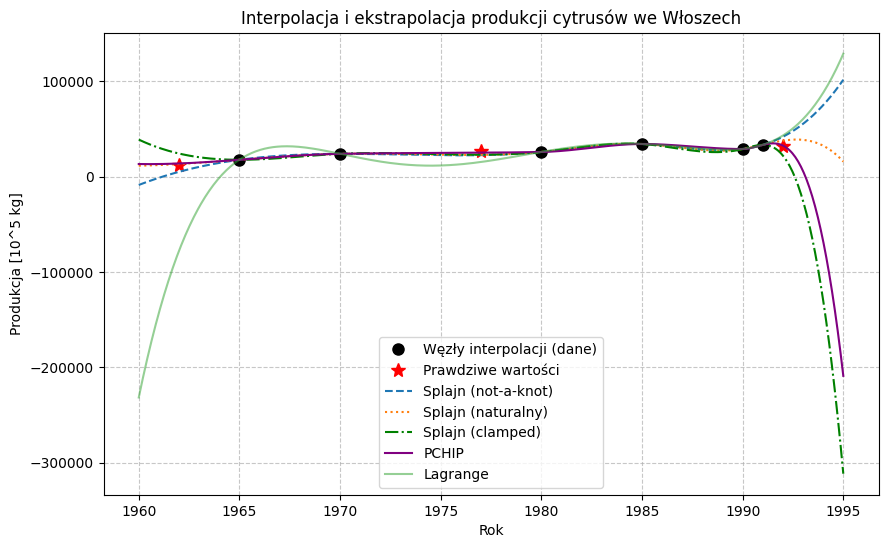

In [2]:
import numpy as np
import pandas as pd
from scipy.interpolate import CubicSpline, lagrange, PchipInterpolator
import matplotlib.pyplot as plt

# 1. Dane wejściowe
roczniki = np.array([1965, 1970, 1980, 1985, 1990, 1991])
produkcja = np.array([17769, 24001, 25961, 34336, 29036, 33417])

# Lata do oszacowania i prawdziwe wartości
lata_szacowane = np.array([1962, 1977, 1992])
prawdziwa_produkcja = np.array([12380, 27403, 32059])

# 2. Szacowanie: Kubiczne funkcje sklejane (Splajny)
# Typ 'not-a-knot' (domyślny w SciPy)
cs_not_a_knot = CubicSpline(roczniki, produkcja, bc_type='not-a-knot')
# Typ 'natural' (druga pochodna na brzegach wynosi 0)
cs_natural = CubicSpline(roczniki, produkcja, bc_type='natural')
# Typ 'clamped'
cs_clamped = CubicSpline(roczniki, produkcja, bc_type='clamped')
cs_pchip = PchipInterpolator(roczniki, produkcja)

pred_not_a_knot = cs_not_a_knot(lata_szacowane)
pred_natural = cs_natural(lata_szacowane)
pred_clamped = cs_clamped(lata_szacowane)

# 3. Szacowanie: Wielomian Lagrange'a
poly_lagrange = lagrange(roczniki, produkcja)
pred_lagrange = poly_lagrange(lata_szacowane)

pred_pchip = cs_pchip(lata_szacowane)

# 4. Funkcja do obliczania błędu względnego
def rel_error(pred, true):
    return np.abs(pred - true) / true * 100

err_not_a_knot = rel_error(pred_not_a_knot, prawdziwa_produkcja)
err_natural = rel_error(pred_natural, prawdziwa_produkcja)
err_clamped = rel_error(pred_clamped, prawdziwa_produkcja)
err_lagrange = rel_error(pred_lagrange, prawdziwa_produkcja)
err_pchip = rel_error(pred_pchip, prawdziwa_produkcja)


# 5. Zestawienie wyników
df_wyniki = pd.DataFrame({
    'Rok': lata_szacowane,
    'Prawdziwa wartość': prawdziwa_produkcja,
    'Splajn (not-a-knot)': np.round(pred_not_a_knot, 0).astype(int),
    'Błąd (not-a-knot) [%]': np.round(err_not_a_knot, 2),
    'Splajn (naturalny)': np.round(pred_natural, 0).astype(int),
    'Błąd (naturalny) [%]': np.round(err_natural, 2),
    'S. clamped': np.round(pred_clamped, 0).astype(int),
    'Błąd Clmp [%]': np.round(err_clamped, 2),
    'PCHIP': np.round(pred_pchip, 0).astype(int),
    'Błąd (PCHIP) [%]': np.round(err_pchip, 2),
    'Lagrange': np.round(pred_lagrange, 0).astype(int),
    'Błąd (Lagrange) [%]': np.round(err_lagrange, 2)
})

print("Zestawienie wyników dla lat 1962, 1977, 1992:")
print(df_wyniki.to_string(index=False))

# 6. Wizualizacja
x_plot = np.linspace(1960, 1995, 500)
plt.figure(figsize=(10, 6))
plt.plot(roczniki, produkcja, 'ko', markersize=8, label='Węzły interpolacji (dane)')
plt.plot(lata_szacowane, prawdziwa_produkcja, 'r*', markersize=10, label='Prawdziwe wartości')

plt.plot(x_plot, cs_not_a_knot(x_plot), label='Splajn (not-a-knot)', linestyle='--')
plt.plot(x_plot, cs_natural(x_plot), label='Splajn (naturalny)', linestyle=':')
plt.plot(x_plot, cs_clamped(x_plot), label='Splajn (clamped)', linestyle='-.', color='green')
plt.plot(x_plot, cs_pchip(x_plot), label='PCHIP', linestyle='-', color='purple')
plt.plot(x_plot, poly_lagrange(x_plot), label='Lagrange', alpha=0.5)

plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.title("Interpolacja i ekstrapolacja produkcji cytrusów we Włoszech")
plt.xlabel("Rok")
plt.ylabel("Produkcja [10^5 kg]")
plt.show()